# Head3D Fuse Evaluation for Paper

这个 Notebook 用于统计一次实验运行（run directory）的结果，并导出论文可用的汇总表。

- 输入：`logs/head3d_fuse/<date>/<time>`
- 输出：
  - 全局统计表
  - 按环境分组统计
  - 关键指标图
  - CSV / LaTeX 导出

In [6]:
# 中文注释保留：这里配置实验目录并导入依赖
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# 修改为你要统计的 run 目录
RUN_DIR = Path("/workspace/code/logs/head3d_fuse/2026-04-09/07-40-24")
assert RUN_DIR.exists(), f"Run directory not found: {RUN_DIR}"

print(f"Using run dir: {RUN_DIR}")

Using run dir: /workspace/code/logs/head3d_fuse/2026-04-09/07-40-24


In [2]:
# 中文注释保留：加载各 person/env 的 JSON 指标

def _load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def collect_metrics(run_dir: Path):
    smoothing_rows = []
    fused_rows = []

    for p in sorted(run_dir.iterdir()):
        if not p.is_dir() or p.name.startswith(".") or p.name in {"env_logs", "workers_logs"}:
            continue

        person_id = p.name
        for env_dir in sorted(p.iterdir()):
            if not env_dir.is_dir():
                continue

            env_name = env_dir.name

            smoothing_path = env_dir / "comparison" / "smoothing_metrics.json"
            fused_path = env_dir / "fused_vs_views_comparison" / "fused_vs_views_metrics.json"

            if smoothing_path.exists():
                m = _load_json(smoothing_path)
                smoothing_rows.append({
                    "person_id": person_id,
                    "env_name": env_name,
                    "mean_difference": m.get("mean_difference", np.nan),
                    "max_difference": m.get("max_difference", np.nan),
                    "std_difference": m.get("std_difference", np.nan),
                    "median_difference": m.get("median_difference", np.nan),
                    "velocity_reduction": m.get("velocity_reduction", np.nan),
                    "acceleration_reduction": m.get("acceleration_reduction", np.nan),
                    "jitter_reduction": m.get("jitter_reduction", np.nan),
                    "fused_jitter": m.get("fused_jitter", np.nan),
                    "smoothed_jitter": m.get("smoothed_jitter", np.nan),
                })

            if fused_path.exists():
                m = _load_json(fused_path)
                mean_dist = m.get("mean_distance_to_views", {})
                std_dist = m.get("std_distance_to_views", {})
                view_jitters = m.get("view_jitters", {})
                consistency = m.get("view_consistency", {})
                fused_jitter = m.get("fused_jitter", {})

                fused_rows.append({
                    "person_id": person_id,
                    "env_name": env_name,
                    "dist_to_front": mean_dist.get("front", np.nan),
                    "dist_to_left": mean_dist.get("left", np.nan),
                    "dist_to_right": mean_dist.get("right", np.nan),
                    "dist_std_front": std_dist.get("front", np.nan),
                    "dist_std_left": std_dist.get("left", np.nan),
                    "dist_std_right": std_dist.get("right", np.nan),
                    "dist_to_centroid": m.get("mean_distance_to_centroid", np.nan),
                    "dist_to_centroid_std": m.get("std_distance_to_centroid", np.nan),
                    "fused_jitter_mean": fused_jitter.get("mean", np.nan),
                    "fused_jitter_std": fused_jitter.get("std", np.nan),
                    "jitter_reduction_vs_front": view_jitters.get("front", {}).get("jitter_reduction_vs_fused", np.nan),
                    "jitter_reduction_vs_left": view_jitters.get("left", {}).get("jitter_reduction_vs_fused", np.nan),
                    "jitter_reduction_vs_right": view_jitters.get("right", {}).get("jitter_reduction_vs_fused", np.nan),
                    "consistency_front_left": consistency.get("front_vs_left", {}).get("mean", np.nan),
                    "consistency_front_right": consistency.get("front_vs_right", {}).get("mean", np.nan),
                    "consistency_left_right": consistency.get("left_vs_right", {}).get("mean", np.nan),
                })

    smoothing_df = pd.DataFrame(smoothing_rows)
    fused_df = pd.DataFrame(fused_rows)
    return smoothing_df, fused_df


smoothing_df, fused_df = collect_metrics(RUN_DIR)

print(f"Smoothing records: {len(smoothing_df)}")
print(f"Fused-vs-view records: {len(fused_df)}")

display(smoothing_df.head())
display(fused_df.head())

Smoothing records: 88
Fused-vs-view records: 88


,person_id,env_name,mean_difference,max_difference,std_difference,median_difference,velocity_reduction,acceleration_reduction,jitter_reduction,fused_jitter,smoothed_jitter
0,01,夜多い,0.003376,0.099072,0.003572,0.002493,73.219627,92.084869,90.180276,0.010046,0.000986
1,01,夜少ない,0.003298,0.134082,0.003382,0.002483,73.429214,92.202858,90.589992,0.009500,0.000894
2,01,昼多い,0.003594,0.129866,0.003859,0.002570,71.998886,91.851387,90.400628,0.010861,0.001043
3,01,昼少ない,0.003389,0.139322,0.004254,0.002357,72.446823,91.986755,91.653441,0.012409,0.001036
4,02,夜多い,0.002922,0.123630,0.003221,0.002277,78.333054,93.084785,92.916494,0.009378,0.000664


,person_id,env_name,dist_to_front,dist_to_left,dist_to_right,dist_std_front,dist_std_left,dist_std_right,dist_to_centroid,dist_to_centroid_std,fused_jitter_mean,fused_jitter_std,jitter_reduction_vs_front,jitter_reduction_vs_left,jitter_reduction_vs_right,consistency_front_left,consistency_front_right,consistency_left_right
0,01,夜多い,0.040974,0.112284,0.051640,0.034276,0.067043,0.038453,0.030756,0.018450,0.010396,0.010119,17.280142,1.128299,4.784036,0.144619,0.076335,0.152682
1,01,夜少ない,0.039723,0.111276,0.048553,0.029006,0.070128,0.036207,0.032480,0.017386,0.010198,0.009646,14.951395,0.515698,-3.442548,0.143249,0.072892,0.149337
2,01,昼多い,0.047814,0.104127,0.055010,0.032929,0.057658,0.036306,0.027197,0.013971,0.010976,0.010971,17.946991,-7.001225,-12.014984,0.139112,0.084221,0.149807
3,01,昼少ない,0.050340,0.103775,0.051815,0.040993,0.057706,0.037197,0.027971,0.016024,0.010368,0.012627,33.453203,-10.079812,-18.961678,0.141948,0.084493,0.147008
4,02,夜多い,0.034777,0.089484,0.043585,0.025841,0.053354,0.033214,0.024182,0.013575,0.009212,0.009662,4.316193,8.299153,9.138345,0.116910,0.064831,0.124684


In [3]:
# 中文注释保留：构建论文可用汇总表（全局 + 分环境）

def summarize_for_paper(df: pd.DataFrame, cols):
    rows = []
    for c in cols:
        s = df[c].dropna()
        rows.append({
            "metric": c,
            "n": int(s.shape[0]),
            "mean": s.mean() if len(s) else np.nan,
            "std": s.std(ddof=1) if len(s) > 1 else np.nan,
            "median": s.median() if len(s) else np.nan,
            "p25": s.quantile(0.25) if len(s) else np.nan,
            "p75": s.quantile(0.75) if len(s) else np.nan,
            "min": s.min() if len(s) else np.nan,
            "max": s.max() if len(s) else np.nan,
        })
    return pd.DataFrame(rows)


smooth_metrics_cols = [
    "mean_difference", "velocity_reduction", "acceleration_reduction",
    "jitter_reduction", "fused_jitter", "smoothed_jitter"
]
fused_metrics_cols = [
    "dist_to_front", "dist_to_left", "dist_to_right", "dist_to_centroid",
    "fused_jitter_mean", "consistency_front_left", "consistency_front_right", "consistency_left_right"
]

smooth_overall = summarize_for_paper(smoothing_df, smooth_metrics_cols)
fused_overall = summarize_for_paper(fused_df, fused_metrics_cols)

print("=== Overall: Smoothing metrics ===")
display(smooth_overall)
print("=== Overall: Fused-vs-view metrics ===")
display(fused_overall)

smooth_by_env = smoothing_df.groupby("env_name")[smooth_metrics_cols].agg(["mean", "std", "median", "count"])
fused_by_env = fused_df.groupby("env_name")[fused_metrics_cols].agg(["mean", "std", "median", "count"])

print("=== By environment: Smoothing metrics ===")
display(smooth_by_env)
print("=== By environment: Fused-vs-view metrics ===")
display(fused_by_env)

=== Overall: Smoothing metrics ===


,metric,n,mean,std,median,p25,p75,min,max
0,mean_difference,88,0.004463,0.001082,0.004225,0.003609,0.005293,0.002729,0.007301
1,velocity_reduction,88,78.468634,2.325773,78.475777,77.138292,80.323055,71.998886,83.642105
2,acceleration_reduction,88,92.964608,0.632265,92.937435,92.453924,93.455193,91.789200,94.583061
3,jitter_reduction,88,91.184312,0.774487,91.168932,90.659249,91.687447,89.291141,92.916494
4,fused_jitter,88,0.013045,0.003425,0.012471,0.010488,0.015107,0.007494,0.022292
5,smoothed_jitter,88,0.001149,0.000310,0.001099,0.000929,0.001313,0.000628,0.002014


=== Overall: Fused-vs-view metrics ===


,metric,n,mean,std,median,p25,p75,min,max
0,dist_to_front,88,0.057376,0.013665,0.056959,0.047174,0.066842,0.032244,0.092002
1,dist_to_left,88,0.093172,0.022783,0.094499,0.074793,0.109294,0.057947,0.171804
2,dist_to_right,88,0.065291,0.019129,0.061859,0.050317,0.076158,0.041084,0.133326
3,dist_to_centroid,88,0.031643,0.005284,0.031267,0.027857,0.035744,0.021239,0.043863
4,fused_jitter_mean,88,0.014038,0.003288,0.013469,0.011300,0.016675,0.008852,0.022559
5,consistency_front_left,88,0.133750,0.018820,0.134429,0.120101,0.144835,0.095064,0.194197
6,consistency_front_right,88,0.108606,0.023870,0.106862,0.088612,0.130018,0.062600,0.152935
7,consistency_left_right,88,0.149254,0.031675,0.141844,0.126974,0.163211,0.107153,0.271864


=== By environment: Smoothing metrics ===


mean_difference                           velocity_reduction                            acceleration_reduction                            jitter_reduction                             \
                    mean       std    median count               mean       std     median count                   mean       std     median count             mean       std     median count   
env_name                                                                                                                                                                                         
夜多い             0.004381  0.001029  0.004209    22          78.405076  1.909889  78.330723    22              92.944586  0.523231  92.951508    22        91.289578  0.874847  91.263265    22   
夜少ない            0.004494  0.001160  0.004352    22          78.178766  2.085878  78.710636    22              92.887792  0.559301  92.874722    22        91.156459  0.818253  91.143843    22   
昼多い             0.004467  0.001092  0.004082    22          78.681471  2.810373  78.869381    22              93.036139  0.757347  93.138615    22        91.019388  0.622483  91.139014    22   
昼少ない            0.004509  0.001115  0.004202    22          78.609221  2.520405  78.275562    22              92.989913  0.695233  92.905113    22        91.271821  0.783385  91.255323    22   

         fused_jitter                           smoothed_jitter                            
                 mean       std    median count            mean       std    median count  
env_name                                                                                   
夜多い          0.012690  0.003035  0.011842    22        0.001107  0.000279  0.001077    22  
夜少ない         0.013397  0.003682  0.012869    22        0.001178  0.000307  0.001121    22  
昼多い          0.012839  0.003616  0.012432    22        0.001153  0.000326  0.001130    22  
昼少ない         0.013253  0.003521  0.012825    22        0.001160  0.000341  0.001091    22

=== By environment: Fused-vs-view metrics ===


dist_to_front                           dist_to_left                           dist_to_right                           dist_to_centroid                           fused_jitter_mean  \
                  mean       std    median count         mean       std    median count          mean       std    median count             mean       std    median count              mean   
env_name                                                                                                                                                                                       
夜多い           0.056625  0.012748  0.056385    22     0.093937  0.026934  0.093207    22      0.063656  0.016751  0.061416    22         0.031445  0.005224  0.030993    22          0.013757   
夜少ない          0.056645  0.015886  0.053768    22     0.092032  0.018800  0.095798    22      0.067815  0.023446  0.064533    22         0.031368  0.005213  0.031992    22          0.014085   
昼多い           0.058997  0.012908  0.057538    22     0.092216  0.023085  0.094916    22      0.063470  0.015861  0.059975    22         0.032022  0.005388  0.031918    22          0.014110   
昼少ない          0.057236  0.013720  0.056044    22     0.094504  0.023105  0.093925    22      0.066221  0.020498  0.063215    22         0.031737  0.005646  0.029950    22          0.014197   

                                   consistency_front_left                           consistency_front_right                           consistency_left_right                            
               std    median count                   mean       std    median count                    mean       std    median count                   mean       std    median count  
env_name                                                                                                                                                                                
夜多い       0.003074  0.013204    22               0.133878  0.021815  0.133163    22                0.106067  0.023618  0.099703    22               0.148382  0.034623  0.137676    22  
夜少ない      0.003533  0.013734    22               0.132497  0.015728  0.134449    22                0.110552  0.026100  0.104914    22               0.150673  0.032262  0.144869    22  
昼多い       0.003366  0.013259    22               0.134235  0.019532  0.133731    22                0.108934  0.023433  0.109957    22               0.146352  0.028715  0.140248    22  
昼少ない      0.003377  0.013335    22               0.134388  0.018980  0.137611    22                0.108871  0.023694  0.109075    22               0.151609  0.032787  0.143114    22

/tmp/ipykernel_583364/2265751043.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=long_dist, x="view", y="distance", ax=axes[1, 0], palette="Set2")
/tmp/ipykernel_583364/2265751043.py:37: UserWarning: Glyph 22812 (\N{CJK UNIFIED IDEOGRAPH-591C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_583364/2265751043.py:37: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_583364/2265751043.py:37: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_583364/2265751043.py:37: UserWarning: Glyph 23569 (\N{CJK UNIFIED IDEOGRAPH-5C11}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_583364/2265751043.py:37: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA})

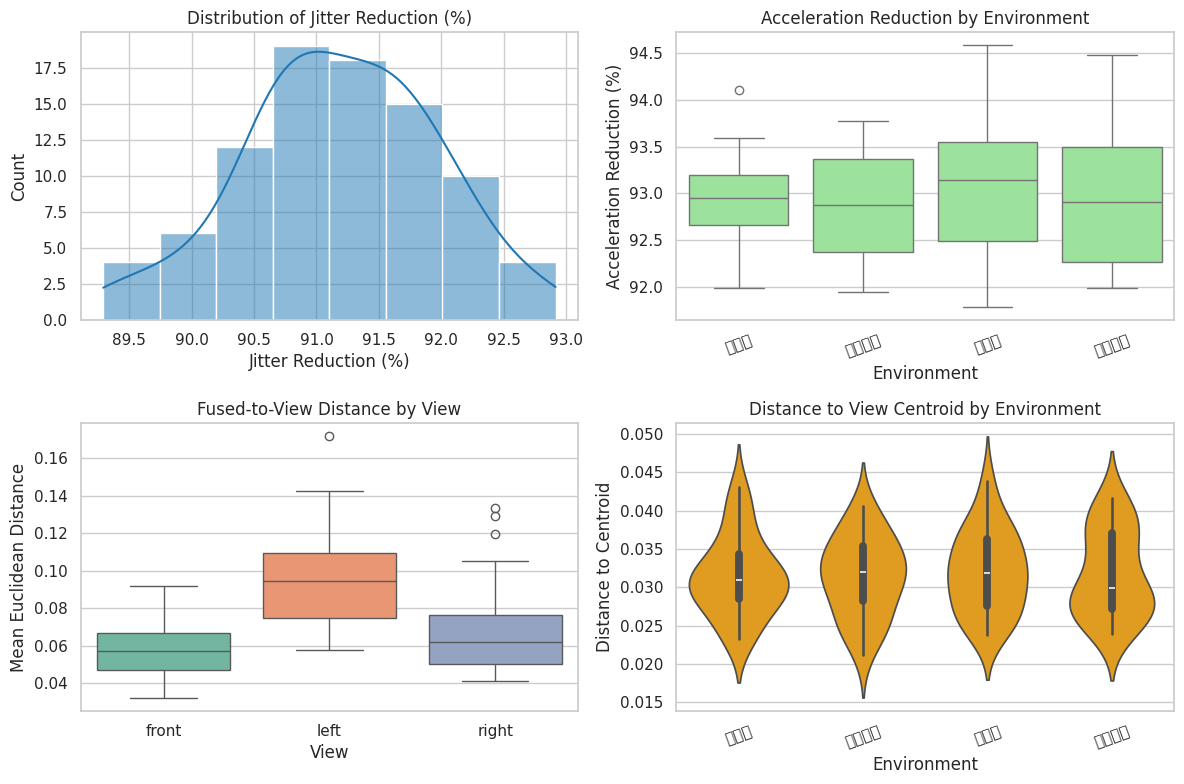

In [4]:
# 中文注释保留：可视化关键指标（论文图可直接截取/再美化）
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1) Jitter reduction distribution
sns.histplot(smoothing_df["jitter_reduction"].dropna(), kde=True, ax=axes[0, 0], color="tab:blue")
axes[0, 0].set_title("Distribution of Jitter Reduction (%)")
axes[0, 0].set_xlabel("Jitter Reduction (%)")
axes[0, 0].set_ylabel("Count")

# 2) Acceleration reduction by environment
sns.boxplot(data=smoothing_df, x="env_name", y="acceleration_reduction", ax=axes[0, 1], color="lightgreen")
axes[0, 1].set_title("Acceleration Reduction by Environment")
axes[0, 1].set_xlabel("Environment")
axes[0, 1].set_ylabel("Acceleration Reduction (%)")
axes[0, 1].tick_params(axis="x", rotation=20)

# 3) Distance to each view (long format)
long_dist = fused_df.melt(
    id_vars=["person_id", "env_name"],
    value_vars=["dist_to_front", "dist_to_left", "dist_to_right"],
    var_name="view",
    value_name="distance",
)
long_dist["view"] = long_dist["view"].str.replace("dist_to_", "", regex=False)
sns.boxplot(data=long_dist, x="view", y="distance", ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Fused-to-View Distance by View")
axes[1, 0].set_xlabel("View")
axes[1, 0].set_ylabel("Mean Euclidean Distance")

# 4) Distance to centroid by environment
sns.violinplot(data=fused_df, x="env_name", y="dist_to_centroid", ax=axes[1, 1], inner="box", color="orange")
axes[1, 1].set_title("Distance to View Centroid by Environment")
axes[1, 1].set_xlabel("Environment")
axes[1, 1].set_ylabel("Distance to Centroid")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [5]:
# 中文注释保留：导出论文表格与中间结果
out_dir = RUN_DIR / "paper_eval_summary"
out_dir.mkdir(parents=True, exist_ok=True)

smoothing_df.to_csv(out_dir / "smoothing_records.csv", index=False)
fused_df.to_csv(out_dir / "fused_vs_view_records.csv", index=False)

smooth_overall.to_csv(out_dir / "smooth_overall_summary.csv", index=False)
fused_overall.to_csv(out_dir / "fused_overall_summary.csv", index=False)

smooth_by_env.to_csv(out_dir / "smooth_summary_by_env.csv")
fused_by_env.to_csv(out_dir / "fused_summary_by_env.csv")

# 导出 LaTeX，方便贴论文
with open(out_dir / "smooth_overall_summary.tex", "w", encoding="utf-8") as f:
    f.write(smooth_overall.to_latex(index=False, float_format="%.4f"))

with open(out_dir / "fused_overall_summary.tex", "w", encoding="utf-8") as f:
    f.write(fused_overall.to_latex(index=False, float_format="%.4f"))

print(f"Saved all outputs to: {out_dir}")
print("Generated files:")
for p in sorted(out_dir.glob("*")):
    print(" -", p.name)

Saved all outputs to: /workspace/code/logs/head3d_fuse/2026-04-09/07-40-24/paper_eval_summary
Generated files:
 - fused_overall_summary.csv
 - fused_overall_summary.tex
 - fused_summary_by_env.csv
 - fused_vs_view_records.csv
 - smooth_overall_summary.csv
 - smooth_overall_summary.tex
 - smooth_summary_by_env.csv
 - smoothing_records.csv
